# Sentinel-2 RGB Processing - Sentinel Hub L1C Optimized

Faithful recreation of the Sentinel Hub L1C Optimized RGB composite processing.

**Source**: https://custom-scripts.sentinel-hub.com/sentinel-2/l1c_optimized/

**L1C vs L2A**: This implements L1C (Top-of-Atmosphere) processing which includes Rayleigh scattering correction for raw satellite data, unlike L2A which is already atmospherically corrected.

**Processing Steps**:
1. Load BRF (Bidirectional Reflectance Factor) data for bands B2, B3, B4
2. Remove minimum Rayleigh scattering (atmospheric correction)
3. Apply contrast enhancement with highlight compression
4. Apply gamma correction with offset (γ=2.3)
5. Apply saturation enhancement (×1.3)
6. Apply sRGB encoding

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

# Output directory
# output_dir = Path(
#     "./simple_integration_output/pnp_scene_forest_water_dem/eradiate_renders"
# )
output_dir = Path(
    "/home/gonzalezm/test/s2gos/simple_integration_output/gobabeb_scene_renders_rpv_sentinel/eradiate_renders"
)

[mitsuba] Warning: Couldn't import the ipywidgets package. Installing this package is required for the system to properly log messages and print in Jupyter notebooks!


In [2]:
# Load BRF (Bidirectional Reflectance Factor) data from Sentinel-2 simulation
# BRF is the reflectance value that Sentinel Hub scripts expect

# band_files = {
#     "B2": "config_simulation_sentinel2_msi_b2.zarr",  # Blue (490nm)
#     "B3": "config_simulation_sentinel2_msi_b3.zarr",  # Green (560nm)
#     "B4": "config_simulation_sentinel2_msi_b4.zarr",  # Red (665nm)
#     "B8": "config_simulation_sentinel2_msi_b8.zarr",
# }


band_files = {
    "B2": "config_simulation_sentinel2_msi_b2.zarr",  # Blue (490nm)
    "B3": "config_simulation_sentinel2_msi_b3.zarr",  # Green (560nm)
    "B4": "config_simulation_sentinel2_msi_b4.zarr",  # Red (665nm)
    # "B8": "config_simulation_sentinel2_msi_b8.zarr",
}

# band_files = {
#     "B2": "config_simulation_hf_updated_sentinel2_msi_b2.zarr",  # Blue (490nm)
#     "B3": "config_simulation_hf_updated_sentinel2_msi_b3.zarr",  # Green (560nm)
#     "B4": "config_simulation_hf_updated_sentinel2_msi_b4.zarr",  # Red (665nm)
# }


brf_data = {}
raw_data = {}
for band, filepath in band_files.items():
    ds = xr.open_zarr(output_dir / filepath)
    print(ds)
    # Use BRF_SRF (BRF with Spectral Response Function applied)
    # BRF is the Bidirectional Reflectance Factor - the correct input for Sentinel Hub scripts
    # Squeeze to remove singleton dimensions (saa, sza)
    raw_data[band] = ds
    brf_data[band] = (
        ds["radiance_srf"].squeeze().values
    )  # Fixed: was using radiance_srf
    print(
        f"{band}: shape={brf_data[band].shape}, range=[{brf_data[band].min():.4f}, {brf_data[band].max():.4f}]"
    )

print("\nLoaded BRF data for RGB composite (350x350 pixels)")

<xarray.Dataset> Size: 256MB
Dimensions:         (w: 9, y_index: 1000, x_index: 1000, saa: 1, sza: 1)
Coordinates:
    bin_wmax        (w) float64 72B dask.array<chunksize=(9,), meta=np.ndarray>
    bin_wmin        (w) float64 72B dask.array<chunksize=(9,), meta=np.ndarray>
  * saa             (saa) float64 8B 180.3
  * sza             (sza) float64 8B 13.14
    vaa             (x_index, y_index) float64 8MB dask.array<chunksize=(250, 250), meta=np.ndarray>
    vza             (x_index, y_index) float64 8MB dask.array<chunksize=(250, 250), meta=np.ndarray>
  * w               (w) float64 72B 450.0 460.0 470.0 ... 510.0 520.0 530.0
    x               (x_index) float64 8kB dask.array<chunksize=(1000,), meta=np.ndarray>
  * x_index         (x_index) int64 8kB 0 1 2 3 4 5 ... 994 995 996 997 998 999
    y               (y_index) float64 8kB dask.array<chunksize=(1000,), meta=np.ndarray>
  * y_index         (y_index) int64 8kB 0 1 2 3 4 5 ... 994 995 996 997 998 999
Data variables:
    brd

In [3]:
# Sentinel Hub L1C Optimized Processing Functions
# Exact translation from JavaScript to Python

# Constants from Sentinel Hub L1C script
MAX_R = 3.0  # max reflectance
MID_R = 0.13  # mid reflectance for contrast adjustment
SAT = 1.3  # saturation enhancement factor (L1C)
GAMMA = 2.3  # gamma correction value (L1C)
G_OFF = 0.01  # gamma offset

# Rayleigh scattering correction constants (L1C only - for TOA data)
RAY_R = 0.013  # Red channel minimum Rayleigh scattering
RAY_G = 0.024  # Green channel minimum Rayleigh scattering
RAY_B = 0.041  # Blue channel minimum Rayleigh scattering

# Pre-compute gamma offset constants
G_OFF_POW = G_OFF**GAMMA
G_OFF_RANGE = (1 + G_OFF) ** GAMMA - G_OFF_POW


def adj(a, tx, ty, max_c):
    """Contrast enhancement with highlight compression.

    This is the exact formula from the Sentinel Hub script:
    ar * (ar * (tx/maxC + ty - 1) - ty) / (ar * (2*tx/maxC - 1) - tx/maxC)
    """
    ar = np.clip(a / max_c, 0, 1)
    numerator = ar * (ar * (tx / max_c + ty - 1) - ty)
    denominator = ar * (2 * tx / max_c - 1) - tx / max_c
    return numerator / denominator


def adj_gamma(b):
    """Gamma correction with offset.

    Formula: ((b + gOff)^gamma - gOffPow) / gOffRange
    """
    return ((b + G_OFF) ** GAMMA - G_OFF_POW) / G_OFF_RANGE


def s_adj(a):
    """Combined adjustment: contrast + gamma.

    This matches the JavaScript: adjGamma(adj(a, midR, 1, maxR))
    """
    return adj_gamma(adj(a, MID_R, 1, MAX_R))


def sat_enh(r, g, b):
    """Saturation enhancement.

    Formula: avgS + channel * sat, where avgS = avg * (1 - sat)
    """
    avg_s = (r + g + b) / 3.0 * (1 - SAT)
    return (
        np.clip(avg_s + r * SAT, 0, 1),
        np.clip(avg_s + g * SAT, 0, 1),
        np.clip(avg_s + b * SAT, 0, 1),
    )


def srgb_encode(c):
    """sRGB encoding (linear to sRGB color space).

    Formula from Sentinel Hub script:
    - c <= 0.0031308: 12.92 * c
    - c > 0.0031308: 1.055 * c^(1/2.4) - 0.055

    Note: JavaScript uses 0.41666666666 which is 1/2.4
    """
    return np.where(
        c <= 0.0031308,
        12.92 * c,
        1.055 * np.power(np.clip(c, 0, 1.0), 1 / 2.4) - 0.055,
    )


print("✅ Sentinel Hub L1C processing functions defined")
print(f"Parameters: maxR={MAX_R}, midR={MID_R}, sat={SAT}, gamma={GAMMA}")
print(f"Rayleigh correction: R={RAY_R}, G={RAY_G}, B={RAY_B}")

✅ Sentinel Hub L1C processing functions defined
Parameters: maxR=3.0, midR=0.13, sat=1.3, gamma=2.3
Rayleigh correction: R=0.013, G=0.024, B=0.041


In [4]:
# Apply the Sentinel Hub L1C processing pipeline

print("Processing bands through Sentinel Hub L1C pipeline...\n")

# Step 1: Extract bands and apply Rayleigh scattering removal (L1C specific)
# BRF values are already reflectance in 0-1 range
# For L1C (Top-of-Atmosphere), we remove minimum Rayleigh scattering
b04 = brf_data["B4"] - RAY_R  # Red channel with Rayleigh removal
b03 = brf_data["B3"] - RAY_G  # Green channel with Rayleigh removal
b02 = brf_data["B2"] - RAY_B  # Blue channel with Rayleigh removal
print("1. Extracted bands and removed Rayleigh scattering:")
print(f"   R={b04.shape} (removed {RAY_R})")
print(f"   G={b03.shape} (removed {RAY_G})")
print(f"   B={b02.shape} (removed {RAY_B})")

# Step 2: Apply contrast + gamma adjustment to each channel (sAdj function)
r_adj = s_adj(b04)
g_adj = s_adj(b03)
b_adj = s_adj(b02)
print(f"2. Applied contrast + gamma adjustment (gamma={GAMMA})")

# Step 3: Apply saturation enhancement (satEnh function)
r_sat, g_sat, b_sat = sat_enh(r_adj, g_adj, b_adj)
print(f"3. Applied saturation enhancement (factor={SAT})")

# Step 4: Apply sRGB encoding
r_final = srgb_encode(r_sat)
g_final = srgb_encode(g_sat)
b_final = srgb_encode(b_sat)
print("4. Applied sRGB encoding")

# Step 5: Stack into RGB image and flip vertically for correct orientation
rgb_sentinel_hub = np.stack([r_final, g_final, b_final], axis=-1)
rgb_sentinel_hub = np.flipud(rgb_sentinel_hub)  # Flip Y axis for correct orientation
rgb_sentinel_hub = np.clip(rgb_sentinel_hub, 0, 1)  # Final clipping
print(f"5. Created RGB composite: {rgb_sentinel_hub.shape}")

print("\n✅ L1C processing complete!")
print(f"Output range: [{rgb_sentinel_hub.min():.4f}, {rgb_sentinel_hub.max():.4f}]")

Processing bands through Sentinel Hub L1C pipeline...

1. Extracted bands and removed Rayleigh scattering:
   R=(1000, 1000) (removed 0.013)
   G=(1000, 1000) (removed 0.024)
   B=(1000, 1000) (removed 0.041)
2. Applied contrast + gamma adjustment (gamma=2.3)
3. Applied saturation enhancement (factor=1.3)
4. Applied sRGB encoding
5. Created RGB composite: (1000, 1000, 3)

✅ L1C processing complete!
Output range: [0.0000, 0.6056]


In [5]:
pixel_selection = np.copy(rgb_sentinel_hub)
# pixel_selection[74, 121, :] = [1, 0, 0]  # Near grass
# pixel_selection[156, 121, :] = [1, 0, 0]  # Coastal on land
# pixel_selection[160, 121, :] = [1, 0, 0]  # Coastal on water
# pixel_selection[45, 200, :] = [1, 0, 0]  # Middle of forest
# pixel_selection[125, 125, :] = [1, 0, 0]  # Middle of forest

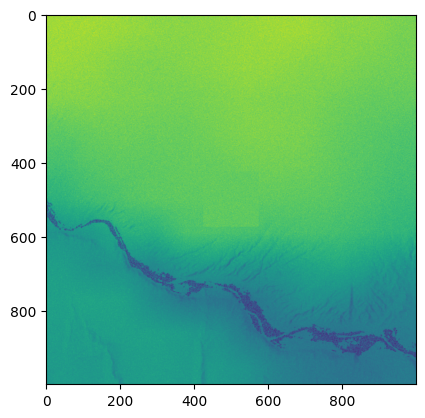

In [6]:
plt.imshow(np.flip(raw_data["B3"]["radiance_srf"].values.squeeze(), 0))

In [7]:
brf_dict = {}
for i in raw_data.keys():
    brf_dict_band = {
        w_val: np.flip(raw_data[i]["radiance"].sel(w=w_val).values.squeeze(), 0)[
            45, 200
        ]
        for w_val in raw_data[i].w.values
    }
    brf_dict = brf_dict | brf_dict_band
print(brf_dict)

{450.0: 0.13337311946670521, 460.0: 0.1397599513824354, 469.99999999999994: 0.1454797989688852, 479.9999999999999: 0.12238821775811629, 489.99999999999994: 0.1260394775631763, 500.0: 0.1282322873593127, 509.99999999999994: 0.13583329850574238, 519.9999999999999: 0.12942845201496744, 529.9999999999999: 0.16206562631481528, 539.9999999999999: 0.1448991524004669, 549.9999999999999: 0.14342692220403214, 559.9999999999999: 0.16168807756970158, 569.9999999999999: 0.15572348561086224, 579.9999999999999: 0.1661003871182924, 649.9999999999999: 0.15595912338820564, 659.9999999999999: 0.16904936621178396, 669.9999999999999: 0.17018207674582755, 679.9999999999999: 0.15813793366874268}


In [8]:
brf_dict.values()

dict_values([0.13337311946670521, 0.1397599513824354, 0.1454797989688852, 0.12238821775811629, 0.1260394775631763, 0.1282322873593127, 0.13583329850574238, 0.12942845201496744, 0.16206562631481528, 0.1448991524004669, 0.14342692220403214, 0.16168807756970158, 0.15572348561086224, 0.1661003871182924, 0.15595912338820564, 0.16904936621178396, 0.17018207674582755, 0.15813793366874268])

In [9]:
def apply_gamma_correction(image: np.ndarray, gamma: float) -> np.ndarray:
    """
    Applies gamma correction to an image.

    Args:
        image: The input image as a NumPy array.
               Can be integer (e.g., uint8) or float.
        gamma: The gamma value for the correction.
               gamma > 1 will brighten the image.
               gamma < 1 will darken the image.

    Returns:
        The gamma-corrected image as a NumPy array with the same
        data type as the input.
    """
    # Store original data type and convert to float for calculation
    original_dtype = image.dtype

    # Determine the maximum possible value based on the data type
    if np.issubdtype(original_dtype, np.integer):
        max_val = np.iinfo(original_dtype).max
    else:
        # Assuming float image is in range [0, 1]
        max_val = 1.0

    # Normalize the image to the range [0, 1]
    image_float = image.astype(np.float32) / max_val

    # Apply the gamma correction formula
    corrected_image = np.power(image_float, 1.0 / gamma)

    # Scale back to the original range and convert to the original data type
    corrected_image = (corrected_image * max_val).astype(original_dtype)

    return corrected_image

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.5617193877696991..2.2126802802085876].


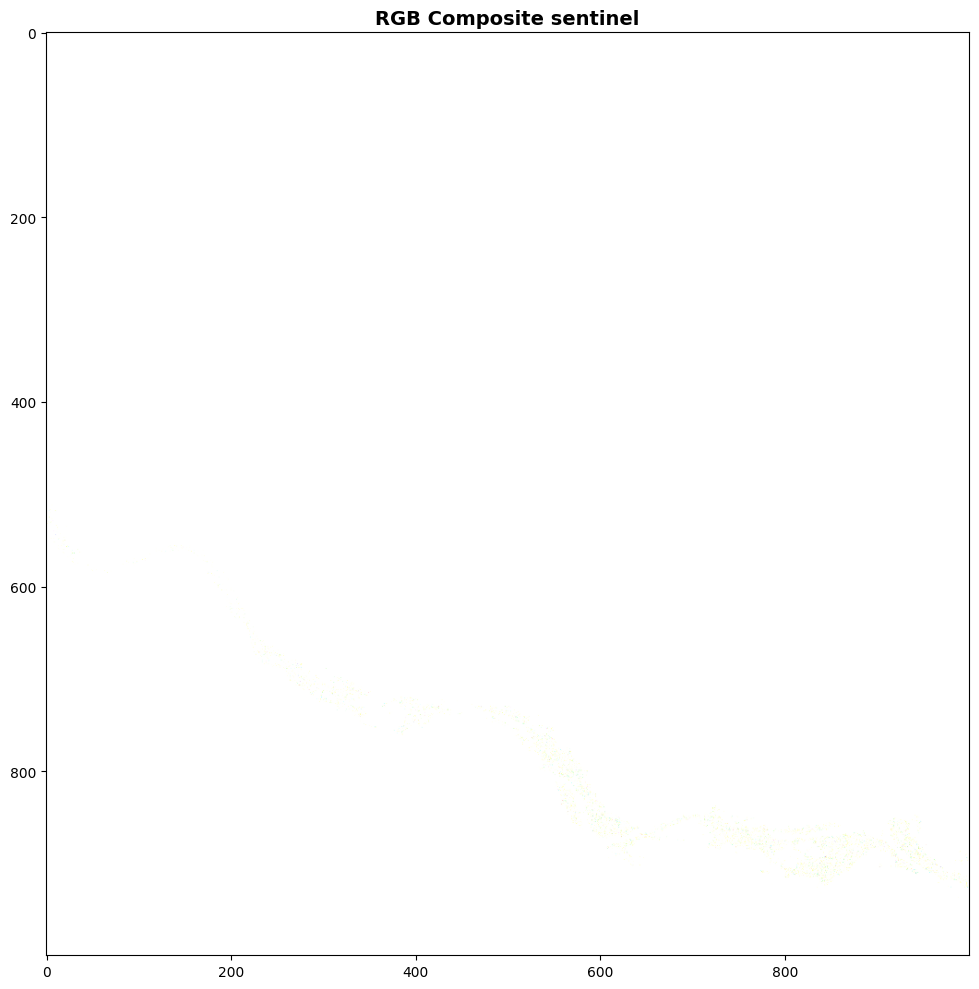

In [10]:
# Display the processed RGB image
rgb_raw = np.stack([b04, b03, b02], axis=-1)
rgb_raw = np.flipud(rgb_raw)
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.imshow(apply_gamma_correction(rgb_raw, 2.2) * 5, aspect="equal")
ax.set_title(
    "RGB Composite sentinel",
    fontsize=14,
    fontweight="bold",
)
ax.axis("on")
plt.tight_layout()
plt.show()

In [11]:
# Save the processed image

# Convert to uint8 for saving
rgb_uint8 = (rgb_sentinel_hub * 255).astype(np.uint8)

# Save as PNG
output_path = output_dir / "sentinel2_rgb_sentinel_hub_l1c_optimized.png"
Image.fromarray(rgb_uint8).save(output_path)

print(f"✅ Saved L1C processed image to: {output_path}")

✅ Saved L1C processed image to: /home/gonzalezm/test/s2gos/simple_integration_output/gobabeb_scene_renders_rpv_sentinel/eradiate_renders/sentinel2_rgb_sentinel_hub_l1c_optimized.png


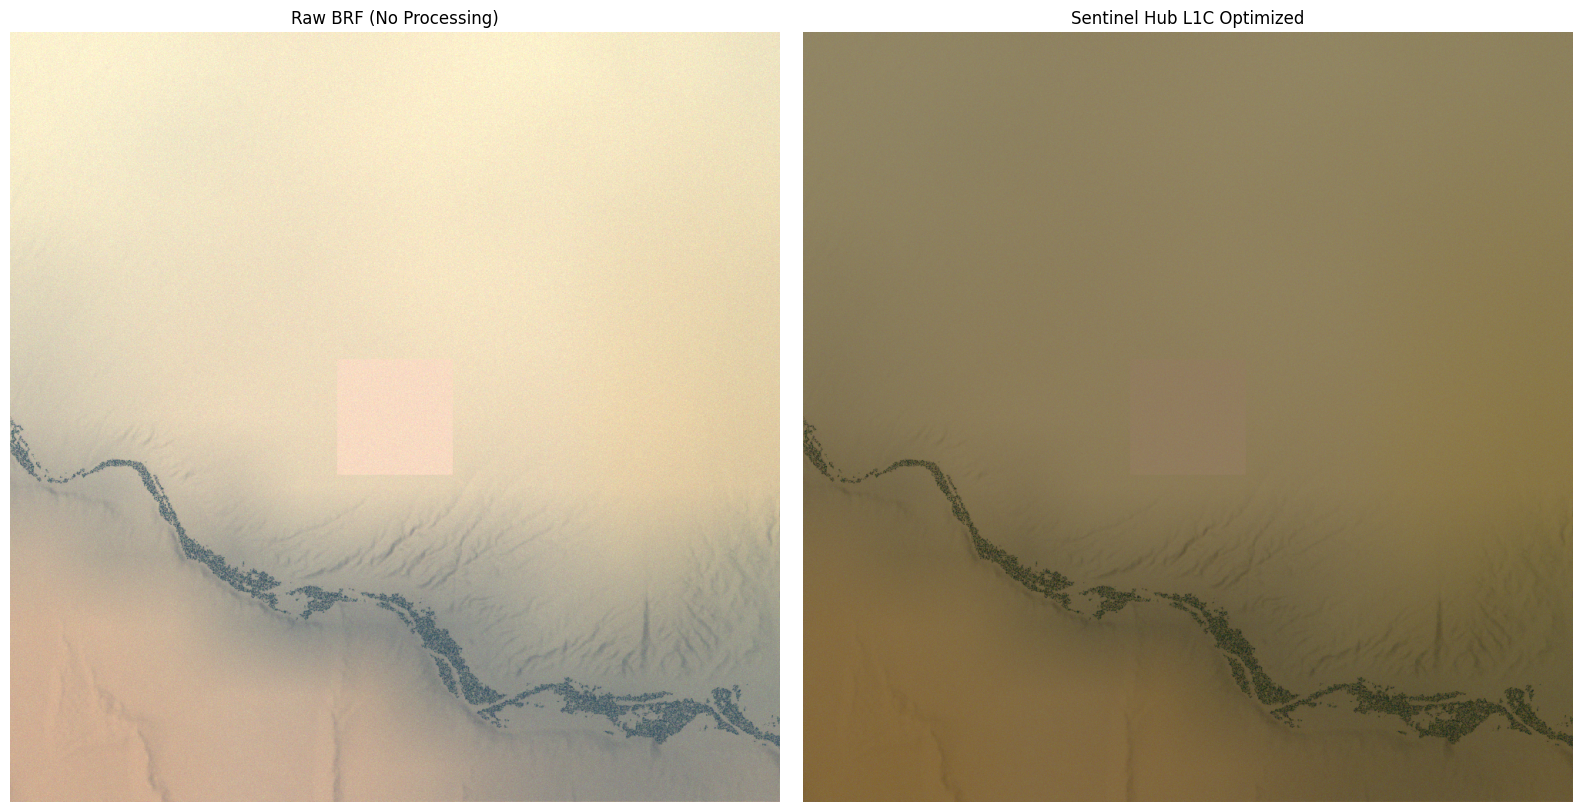


L1C processing applies:
  - Rayleigh scattering removal (atmospheric correction)
  - Contrast enhancement with highlight compression
  - Gamma correction (γ=2.3)
  - Saturation enhancement (×1.3)
  - sRGB color space encoding


In [12]:
# Optional: Create comparison with raw BRF data

# Create raw RGB from BRF (simple stacking, no processing)
# Using the original BRF data without Rayleigh correction for comparison
rgb_raw = np.stack([brf_data["B4"], brf_data["B3"], brf_data["B2"]], axis=-1)
rgb_raw = np.flipud(rgb_raw)
# Normalize raw for display (clip at 99th percentile)
p99 = np.percentile(rgb_raw, 99)
rgb_raw_display = np.clip(rgb_raw / p99, 0, 1)

# Side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
Image.fromarray((rgb_raw_display * 255).astype(np.uint8)).save(
    output_dir / "sentinel2_rgb.png"
)
axes[0].imshow(rgb_raw_display, aspect="equal")
axes[0].set_title("Raw BRF (No Processing)", fontsize=12)
axes[0].axis("off")

axes[1].imshow(rgb_sentinel_hub, aspect="equal")
axes[1].set_title("Sentinel Hub L1C Optimized", fontsize=12)
axes[1].axis("off")

plt.tight_layout()
plt.show()

print("\nL1C processing applies:")
print("  - Rayleigh scattering removal (atmospheric correction)")
print("  - Contrast enhancement with highlight compression")
print("  - Gamma correction (γ=2.3)")
print("  - Saturation enhancement (×1.3)")
print("  - sRGB color space encoding")